# 🧮 Token & Cost Estimator

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/llmops-genai-platform/token-cost-estimator/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=llmops-genai-platform/token-cost-estimator/demo.ipynb)

**Price an LLM feature before you build it.**

Surprise API bills are a design-time failure, not a billing failure. By the time the invoice
lands, the architecture that produced it is already shipped. This notebook prices a workload
*before* the integration exists: describe the prompt shape and the volume, and get a monthly
forecast on every candidate model, plus the levers that actually move the number.

> Day 85 (`llm-cost-tracker`) answers **"what did we spend?"**
> This one answers **"what will this cost, and on which model?"**

### What this notebook covers
1. Estimating tokens without a tokenizer (and why heuristic is the right call here)
2. Describing a workload: prompt, context, output, volume, retries, cache
3. Pricing one workload across four models
4. The whole-product bill - rolling three features up
5. Break-even: how much traffic a budget buys on each model
6. Sensitivity - which lever is worth your engineering time
7. Chart: model spread + lever comparison
8. Try your own workload

## Step 1 - Estimate tokens without a tokenizer

Design-time estimates want to be right within ~10-15%, not exact. Exact counts come from the
provider at runtime. So instead of downloading a tokenizer, use a characters-per-token ratio -
English prose sits near 4.0 chars/token, while code and JSON are denser in punctuation and
tokenize *worse* (fewer chars per token, so more tokens for the same text).

That density difference matters: the same 10 KB of content costs ~40% more as JSON than as prose.

In [1]:
from __future__ import annotations

import math
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

# USD per 1,000,000 tokens (input, output). EXAMPLE rates - edit for your contract.
PRICING: Dict[str, Dict[str, float]] = {
    "premium-large": {"in": 15.00, "out": 75.00},
    "balanced-mid":  {"in":  3.00, "out": 15.00},
    "fast-small":    {"in":  0.80, "out":  4.00},
    "budget-nano":   {"in":  0.15, "out":  0.60},
}

CHARS_PER_TOKEN: Dict[str, float] = {"prose": 4.0, "code": 3.0, "json": 2.8, "cjk": 1.5}


def estimate_tokens(text: str, kind: str = "prose") -> int:
    """Heuristic token count - no tokenizer download, no network call."""
    if not text:
        return 0
    cpt = CHARS_PER_TOKEN.get(kind, CHARS_PER_TOKEN["prose"])
    return max(1, math.ceil(len(text) / cpt))


sample = "You are a support assistant. Answer only from the provided context. " * 20
for kind in CHARS_PER_TOKEN:
    print(f"{kind:>6}: {estimate_tokens(sample, kind):>5,} tokens for {len(sample):,} chars")

 prose:   340 tokens for 1,360 chars
  code:   454 tokens for 1,360 chars
  json:   486 tokens for 1,360 chars
   cjk:   907 tokens for 1,360 chars


## Step 2 - Describe the workload

A workload is one feature's traffic. Two things people forget when they forecast:

- **Retries are billed calls.** A 5% retry rate is 5% more spend, not a rounding error.
- **Cache hits are free calls.** A 30% hit rate cuts the bill 30% - and retrying a cache hit
  costs nothing, so the order of operations matters: retries apply to *misses* only.

The edge case worth guarding: someone types `15` for a 15% rate instead of `0.15`. That inflates
a forecast 100x and it looks plausible in a spreadsheet. Better to fail loudly.

In [2]:
@dataclass
class Workload:
    """One feature's LLM traffic, described at design time. Token fields are PER CALL."""

    name: str
    system_tokens: int = 0
    user_tokens: int = 0
    context_tokens: int = 0     # retrieved RAG chunks, few-shot examples, tool schemas
    output_tokens: int = 0
    calls_per_month: int = 0
    retry_rate: float = 0.0     # 0.15 => 15% of calls retried once
    cache_hit_rate: float = 0.0
    kind: str = "prose"

    def __post_init__(self) -> None:
        rates = (("retry_rate", self.retry_rate), ("cache_hit_rate", self.cache_hit_rate))
        for label, rate in rates:
            if not 0.0 <= rate <= 1.0:
                raise ValueError(
                    f"{self.name}: {label}={rate} must be a fraction in [0, 1] "
                    f"(use 0.15 for 15%, not 15)"
                )

    @property
    def input_tokens(self) -> int:
        return self.system_tokens + self.user_tokens + self.context_tokens

    @property
    def billed_calls(self) -> float:
        """Only misses reach the provider; retries are extra attempts on those misses."""
        misses = self.calls_per_month * (1.0 - self.cache_hit_rate)
        return misses * (1.0 + self.retry_rate)


rag = Workload(
    name="support-rag-bot",
    system_tokens=600, user_tokens=120, context_tokens=4_000, output_tokens=350,
    calls_per_month=40_000, retry_rate=0.05, cache_hit_rate=0.30,
)

print(f"{rag.name}: {rag.input_tokens:,} in / {rag.output_tokens:,} out per call")
print(f"{rag.calls_per_month:,} attempted -> {rag.billed_calls:,.0f} billed calls/mo")
print(f"context is {rag.context_tokens / rag.input_tokens:.0%} of the input tokens")

# The guard in action:
try:
    Workload(name="oops", retry_rate=15)
except ValueError as e:
    print(f"\ncaught: {e}")

support-rag-bot: 4,720 in / 350 out per call
40,000 attempted -> 29,400 billed calls/mo
context is 85% of the input tokens

caught: oops: retry_rate=15 must be a fraction in [0, 1] (use 0.15 for 15%, not 15)


## Step 3 - Price it across every model

Same traffic, four models. The spread is the whole point: model choice moves this bill by
roughly 100x, which is more than any prompt optimization you will ever do.

`input_cost_share` is the number to read second - it says how much of the bill is *prompt*
rather than *completion*.

In [3]:
def call_cost(model: str, input_tokens: int, output_tokens: int) -> float:
    p = PRICING[model]
    return (input_tokens * p["in"] + output_tokens * p["out"]) / 1_000_000


def project(w: Workload, model: str) -> Dict[str, float]:
    per_call = call_cost(model, w.input_tokens, w.output_tokens)
    monthly = per_call * w.billed_calls
    in_cost = w.input_tokens * PRICING[model]["in"]
    out_cost = w.output_tokens * PRICING[model]["out"]
    return {
        "workload": w.name, "model": model,
        "per_call_usd": round(per_call, 6),
        "billed_calls": round(w.billed_calls, 1),
        "monthly_usd": round(monthly, 2),
        "annual_usd": round(monthly * 12, 2),
        "input_cost_share": round(in_cost / max(1e-12, in_cost + out_cost), 3),
    }


def compare_models(w: Workload, models: Optional[List[str]] = None) -> List[Dict[str, float]]:
    rows = [project(w, m) for m in (models or list(PRICING))]
    return sorted(rows, key=lambda r: r["monthly_usd"])


rows = compare_models(rag)
print(f"{'model':<15}{'$/call':>12}{'$/month':>13}{'$/year':>14}{'input share':>13}")
print("-" * 67)
for r in rows:
    print(f"{r['model']:<15}{r['per_call_usd']:>12.6f}{r['monthly_usd']:>13,.2f}"
          f"{r['annual_usd']:>14,.2f}{r['input_cost_share']:>12.0%}")

spread = rows[-1]["monthly_usd"] / rows[0]["monthly_usd"]
print(f"\n{spread:.0f}x spread between cheapest and dearest on identical traffic.")
print(f"Input (prompt) is {rows[0]['input_cost_share']:.0%} of this bill - "
      "so trimming CONTEXT beats trimming output here.")

model                $/call      $/month        $/year  input share
-------------------------------------------------------------------
budget-nano        0.000918        26.99        323.87         77%
fast-small         0.005176       152.17      1,826.09         73%
balanced-mid       0.019410       570.65      6,847.85         73%
premium-large      0.097050     2,853.27     34,239.24         73%

106x spread between cheapest and dearest on identical traffic.
Input (prompt) is 77% of this bill - so trimming CONTEXT beats trimming output here.


## Step 4 - The whole-product bill

Finance never asks about one feature. Roll all three up and a pattern shows: **one feature
dominates on every model.** That reframes the work - fix the top line item instead of
downgrading everything uniformly.

Note the shapes differ wildly. The classifier makes 5x more calls than the RAG bot but costs
less, because it emits a 20-token label. Volume is not cost; tokens × volume is cost.

In [4]:
def portfolio(workloads: List[Workload], model: str) -> Dict[str, float]:
    rows = [project(w, model) for w in workloads]
    total = round(sum(r["monthly_usd"] for r in rows), 2)
    biggest = max(rows, key=lambda r: r["monthly_usd"])
    return {
        "model": model, "monthly_usd": total, "annual_usd": round(total * 12, 2),
        "rows": rows, "top_line_item": biggest["workload"],
        "top_line_share": round(biggest["monthly_usd"] / total, 3) if total else 0.0,
    }


workloads = [
    rag,
    Workload(name="ticket-classifier", system_tokens=400, user_tokens=250, context_tokens=0,
             output_tokens=20, calls_per_month=200_000, retry_rate=0.02, cache_hit_rate=0.10,
             kind="json"),
    Workload(name="monthly-report-writer", system_tokens=900, user_tokens=6_000,
             context_tokens=12_000, output_tokens=3_000, calls_per_month=300,
             retry_rate=0.10, cache_hit_rate=0.0),
]

print(f"{'model':<15}{'$/month':>12}{'$/year':>14}   top line item")
print("-" * 68)
for m in PRICING:
    p = portfolio(workloads, m)
    print(f"{m:<15}{p['monthly_usd']:>12,.2f}{p['annual_usd']:>14,.2f}   "
          f"{p['top_line_item']} ({p['top_line_share']:.0%})")

print("\nPer-feature detail on balanced-mid:")
for r in portfolio(workloads, "balanced-mid")["rows"]:
    print(f"  {r['workload']:<24}{r['billed_calls']:>12,.0f} calls  ${r['monthly_usd']:>10,.2f}/mo")

model               $/month        $/year   top line item
--------------------------------------------------------------------
premium-large      5,086.57     61,038.84   support-rag-bot (56%)
balanced-mid       1,017.31     12,207.72   support-rag-bot (56%)
fast-small           271.28      3,255.36   support-rag-bot (56%)
budget-nano           48.62        583.44   support-rag-bot (56%)

Per-feature detail on balanced-mid:
  support-rag-bot               29,400 calls  $    570.65/mo
  ticket-classifier            183,600 calls  $    413.10/mo
  monthly-report-writer            330 calls  $     33.56/mo


## Step 5 - Break-even: what a budget actually buys

This is the number that ends the "can't we just use the big model?" conversation. Same budget,
same workload shape, two models - how much traffic does each cover?

In [5]:
def break_even_volume(w: Workload, cheap_model: str, premium_model: str,
                      monthly_budget: float) -> Dict[str, float]:
    out: Dict[str, object] = {}
    for label, model in (("cheap", cheap_model), ("premium", premium_model)):
        per_call = call_cost(model, w.input_tokens, w.output_tokens)
        per_billed = per_call * (1.0 + w.retry_rate)
        billable = monthly_budget / per_billed if per_billed else float("inf")
        # gross back up: cache hits are free, so they don't consume budget
        covered = billable / max(1e-12, 1.0 - w.cache_hit_rate)
        out[label] = {"model": model, "per_call_usd": round(per_call, 6),
                      "calls_covered": int(covered)}
    out["premium_multiple"] = round(
        out["premium"]["per_call_usd"] / out["cheap"]["per_call_usd"], 1)
    out["monthly_budget"] = monthly_budget
    return out


be = break_even_volume(rag, "fast-small", "premium-large", 500.0)
print(f"On a ${be['monthly_budget']:,.0f}/mo budget, for the {rag.name} workload:\n")
print(f"  {be['cheap']['model']:<15}{be['cheap']['calls_covered']:>10,} calls/mo")
print(f"  {be['premium']['model']:<15}{be['premium']['calls_covered']:>10,} calls/mo"
      f"   ({be['premium_multiple']}x per-call price)")
ratio = be["cheap"]["calls_covered"] / max(1, be["premium"]["calls_covered"])
print(f"\nSame money buys {ratio:.0f}x more traffic on the cheap model.")
print("Route the easy majority there; reserve the premium model for calls that need it.")

On a $500/mo budget, for the support-rag-bot workload:

  fast-small        131,428 calls/mo
  premium-large       7,009 calls/mo   (18.8x per-call price)

Same money buys 19x more traffic on the cheap model.
Route the easy majority there; reserve the premium model for calls that need it.


## Step 6 - Sensitivity: which lever earns your engineering time

Scale one lever, re-project, measure the spread. Widest spread wins.

The result here contradicts the popular heuristic. "Output tokens cost 3-5x input" is true
*per token* - but this workload sends 4,720 input tokens to get 350 output tokens, so the
**context** lever dominates. Retrieve 4 chunks instead of 8 and you save more than any amount
of prompting the model to be terse.

In [6]:
def sensitivity(w: Workload, model: str, lever: str,
                factors: Tuple[float, ...] = (0.5, 0.75, 1.0, 1.5, 2.0)) -> List[Dict[str, float]]:
    valid = {"volume", "output_tokens", "context_tokens", "cache_hit_rate"}
    if lever not in valid:
        raise ValueError(f"lever must be one of {sorted(valid)}")
    base = project(w, model)["monthly_usd"]
    rows = []
    for f in factors:
        kwargs = dict(name=w.name, system_tokens=w.system_tokens, user_tokens=w.user_tokens,
                      context_tokens=w.context_tokens, output_tokens=w.output_tokens,
                      calls_per_month=w.calls_per_month, retry_rate=w.retry_rate,
                      cache_hit_rate=w.cache_hit_rate, kind=w.kind)
        if lever == "volume":
            kwargs["calls_per_month"] = int(w.calls_per_month * f)
        elif lever == "cache_hit_rate":
            kwargs["cache_hit_rate"] = min(1.0, w.cache_hit_rate * f)  # a fraction can't exceed 1
        else:
            kwargs[lever] = int(kwargs[lever] * f)
        monthly = project(Workload(**kwargs), model)["monthly_usd"]
        rows.append({"lever": lever, "factor": f, "monthly_usd": monthly,
                     "delta_usd": round(monthly - base, 2),
                     "delta_pct": round((monthly - base) / base * 100, 1) if base else 0.0})
    return rows


LEVERS = ("volume", "context_tokens", "output_tokens", "cache_hit_rate")
sens = {lv: sensitivity(rag, "balanced-mid", lv) for lv in LEVERS}

base_cost = project(rag, "balanced-mid")["monthly_usd"]
print(f"balanced-mid, {rag.name} - base = ${base_cost:,.2f}/mo\n")
print(f"{'lever':<16}{'0.5x':>11}{'2.0x':>11}{'spread':>12}")
print("-" * 50)
for lv, rws in sens.items():
    print(f"{lv:<16}{rws[0]['monthly_usd']:>11,.2f}{rws[-1]['monthly_usd']:>11,.2f}"
          f"{abs(rws[-1]['monthly_usd'] - rws[0]['monthly_usd']):>12,.2f}")

balanced-mid, support-rag-bot - base = $570.65/mo

lever                  0.5x       2.0x      spread
--------------------------------------------------
volume               285.33   1,141.31      855.98
context_tokens       394.25     923.45      529.20
output_tokens        493.48     725.00      231.52
cache_hit_rate       692.94     326.09      366.85


## Step 7 - The picture

Left: the model spread on one workload (log scale, because it is that wide).
Right: each lever's effect on the monthly bill, same workload, one model.

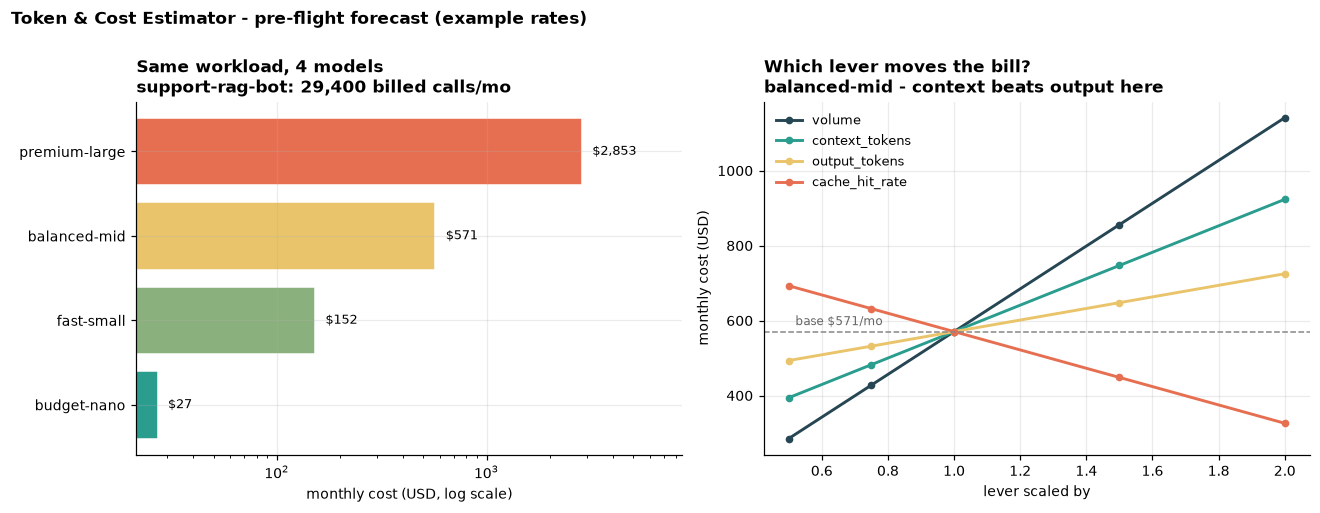

In [7]:
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.6))

# --- left: model spread
mr = compare_models(rag)
names = [r["model"] for r in mr]
vals = [r["monthly_usd"] for r in mr]
colors = ["#2a9d8f", "#8ab17d", "#e9c46a", "#e76f51"]
bars = ax1.barh(names, vals, color=colors, edgecolor="white")
ax1.set_xscale("log")
ax1.set_xlabel("monthly cost (USD, log scale)")
ax1.set_title(f"Same workload, 4 models\n{rag.name}: {rag.billed_calls:,.0f} billed calls/mo",
              loc="left", fontweight="bold")
for b, v in zip(bars, vals):
    ax1.text(v * 1.12, b.get_y() + b.get_height() / 2, f"${v:,.0f}", va="center", fontsize=8.5)
ax1.set_xlim(right=max(vals) * 3)

# --- right: levers
base = project(rag, "balanced-mid")["monthly_usd"]
lever_colors = {"volume": "#264653", "context_tokens": "#2a9d8f",
                "output_tokens": "#e9c46a", "cache_hit_rate": "#e76f51"}
for lv, rws in sens.items():
    ax2.plot([r["factor"] for r in rws], [r["monthly_usd"] for r in rws],
             marker="o", ms=4, lw=1.9, color=lever_colors[lv], label=lv)
ax2.axhline(base, ls="--", lw=1, color="#888")
ax2.text(0.52, base * 1.03, f"base ${base:,.0f}/mo", fontsize=8, color="#666")
ax2.set_xlabel("lever scaled by")
ax2.set_ylabel("monthly cost (USD)")
ax2.set_title("Which lever moves the bill?\nbalanced-mid - context beats output here",
              loc="left", fontweight="bold")
ax2.legend(frameon=False, fontsize=8.5)

fig.suptitle("Token & Cost Estimator - pre-flight forecast (example rates)",
             fontsize=11, fontweight="bold", x=0.005, ha="left", y=1.0)
fig.tight_layout()
fig.savefig("cost_estimate.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary - what the forecast said

| Question | Answer (example rates) |
|---|---|
| Cheapest for the RAG bot | `budget-nano` ~$27/mo vs ~$2,853/mo `premium-large` - **106x** |
| Whole-product bill (3 features) | ~$49/mo on `budget-nano` → ~$5,087/mo on `premium-large` |
| Who dominates the bill | `support-rag-bot`, ~56% on *every* model |
| $500/mo budget buys | ~131k calls on `fast-small` vs ~7k on `premium-large` |
| Biggest lever after model choice | **volume**, then **context tokens** - output length is third |

**The takeaway:** model choice and retrieval width set your bill. Prompt wordsmithing does not.
Forecast at design time, then route per-call (Day 90), cache aggressively (Day 86), and log the
real numbers as they land (Day 85).

## Try your own workload

Replace the numbers with your feature and re-run. Uncomment and edit.

In [8]:
# --- your workload -------------------------------------------------------
# mine = Workload(
#     name="my-feature",
#     system_tokens=estimate_tokens(open("my_system_prompt.txt").read()),  # or a number
#     user_tokens=200,
#     context_tokens=2_000,        # retrieved chunks + few-shot + tool schemas
#     output_tokens=500,
#     calls_per_month=25_000,
#     retry_rate=0.03,
#     cache_hit_rate=0.20,
# )
#
# for r in compare_models(mine):
#     print(f"{r['model']:<15}${r['monthly_usd']:>10,.2f}/mo  "
#           f"(input is {r['input_cost_share']:.0%} of the bill)")
#
# print(break_even_volume(mine, "fast-small", "premium-large", monthly_budget=750.0))
#
# for lv in ("volume", "context_tokens", "output_tokens", "cache_hit_rate"):
#     rws = sensitivity(mine, "balanced-mid", lv, factors=(0.5, 2.0))
#     print(f"{lv:<16}spread ${abs(rws[-1]['monthly_usd'] - rws[0]['monthly_usd']):>10,.2f}")

print("Edit the block above with your own numbers, then re-run this cell.")

Edit the block above with your own numbers, then re-run this cell.


---

**Day 125** of the daily FDE build - part of the **LLMOps & GenAI Platform** product line.

Companion pieces: **Day 85** `llm-cost-tracker` (log the real spend), **Day 86** `semantic-cache`
(raise the hit rate), **Day 90** `llm-router` (send each call to the cheapest model that can
handle it).

Run the interactive Streamlit version:

```bash
pip install -r requirements.txt
streamlit run app.py
```

Or the CLI forecast: `python estimate.py`

← [Back to the portfolio](https://github.com/phoebefu6/phoebe-the-builder)